In [5]:
import os
import pickle
import hdbscan
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch


In [2]:
graphs = pickle.load(open("graphs.pkl", "rb"))

In [3]:
all_types = [
    'common_room', 
    'master_room', 
    'living_room',  
    'balcony',       
    'bathroom',      
    'kitchen',     
    'storage',      
    'dining',        
]

G = 8
num_cells = G * G  # = 256
T = len(all_types)  # = 8
type_to_idx = {t: i for i, t in enumerate(all_types)}

print(f"Number of types T = {T}, grid per type = {G}×{G} ({num_cells} cells), total features = {T*num_cells}")

Number of types T = 8, grid per type = 8×8 (64 cells), total features = 512


In [4]:
def extract_feature_matrix(floorplans, all_types, G=16, image_size=256):
    """
    Args:
      - floorplans: list of dicts, each with keys "filename" and "rooms".
      - all_types: list of all room‐type strings (length T).
      - G: grid resolution per axis (grid is G×G).
      - image_size: 256 (since each image is 256×256).
    
    Returns:
      - X: np.ndarray of shape (N_floorplans, T * G * G)
      - filenames: list of filenames, length N_floorplans
    """
    N = len(floorplans)
    T = len(all_types)
    type_to_idx = {t: i for i, t in enumerate(all_types)}
    D = T * G * G
    
    X = np.zeros((N, D), dtype=float)
    filenames = [None] * N
    
    for i, fp in enumerate(floorplans):
        filenames[i] = fp["filename"]
        rooms = fp["rooms"]
        
        # 2a) Collect all raw areas (for normalization)
        areas = np.array([room["area"] for room in rooms], dtype=float)
        total_area = areas.sum() if areas.sum() > 0 else 1.0
        # norm_areas = areas / total_area  # so sum(norm_areas) == 1 if normalizing to use percentage
        norm_areas = areas / (image_size * image_size) # if normalizing to use the absolute room area
        
        # 2b) Process each room
        for ridx, room in enumerate(rooms):
            rtype = room["type"]
            if rtype not in type_to_idx:
                # skip unexpected type
                continue
            t_idx = type_to_idx[rtype]
            
            cx_raw, cy_raw = room["centroid"]
            # 2c) Normalize centroid into [0,1)
            cx = np.clip(cx_raw / image_size, 0.0, 1.0 - 1e-9)
            cy = np.clip(cy_raw / image_size, 0.0, 1.0 - 1e-9)
            
            # 2d) Which grid cell?
            gx = int(cx * G)   # from 0..(G−1)
            gy = int(cy * G)   # from 0..(G−1)
            cell_idx = gy * G + gx
            
            # 2e) Accumulate normalized area into that bin
            X[i, t_idx * (G*G) + cell_idx] += norm_areas[ridx]
            
        # next floorplan…
    
    return X, filenames

# Example usage:
X_raw, filenames = extract_feature_matrix(graphs, all_types, G=G, image_size=256)
print("Raw feature‐matrix shape:", X_raw.shape)
# e.g. (70000, 8*256 = 2048)



Raw feature‐matrix shape: (80788, 512)


In [5]:
# (Optionally) put into a DataFrame for easy column names
colnames = []
for t in all_types:
    for gy in range(G):
        for gx in range(G):
            colnames.append(f"{t}_cell{gy*G + gx}")
df_feats = pd.DataFrame(X_raw, index=filenames, columns=colnames)
df_feats.head(3)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_feats.values)

In [32]:
X_scaled

mask = np.any(X_scaled != 0, axis=0)
X_scaled_nonzero_cols = X_scaled[:, mask]
X_scaled_nonzero_cols.shape

(80788, 351)

In [6]:
pca = PCA(n_components=50, random_state=42)
X_pca50 = pca.fit_transform(X_scaled)   # now shape is (80k × 50)

In [ ]:
# clusterer = hdbscan.HDBSCAN(
#     min_cluster_size=50,
#     min_samples=10,
#     metric="euclidean",
#     cluster_selection_method="eom"
# )

# # 2) Fit on X_scaled
# cluster_labels_hdb = clusterer.fit_predict(X_scaled)
# # cluster_labels_hdb is length‐N, each entry ∈ {−1, 0,1,2,...} 
# # where −1 means “noise.”

# # Count clusters (excluding noise)
# unique = np.unique(cluster_labels_hdb)
# num_clusters = len(unique[unique >= 0])
# num_noise = np.sum(cluster_labels_hdb == -1)
# print(f"HDBSCAN found {num_clusters} clusters (labels ≥0), plus {num_noise} noise points.")

# # For each cluster_id ≥ 0, print its size:
# from collections import Counter
# cnt = Counter(cluster_labels_hdb)
# for label, size in sorted(cnt.items()):
#     if label == -1:
#         print(f"  Noise points: {size}")
#     else:
#         print(f"  Cluster {label}: {size} plans")

/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN found 8 clusters (labels ≥0), plus 17703 noise points.
  Noise points: 17703
  Cluster 0: 55 plans
  Cluster 1: 79 plans
  Cluster 2: 58 plans
  Cluster 3: 103 plans
  Cluster 4: 55 plans
  Cluster 5: 87 plans
  Cluster 6: 62595 plans
  Cluster 7: 53 plans


In [ ]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    # cluster_selection_method="leaf",
    core_dist_n_jobs=4 
)

# 2) Fit on X_scaled
cluster_labels_hdb = clusterer.fit_predict(X_pca50)
# cluster_labels_hdb is length‐N, each entry ∈ {−1, 0,1,2,...} 
# where −1 means “noise.”

# Count clusters (excluding noise)
unique = np.unique(cluster_labels_hdb)
num_clusters = len(unique[unique >= 0])
num_noise = np.sum(cluster_labels_hdb == -1)
print(f"HDBSCAN found {num_clusters} clusters (labels ≥0), plus {num_noise} noise points.")

# For each cluster_id ≥ 0, print its size:
from collections import Counter
cnt = Counter(cluster_labels_hdb)
for label, size in sorted(cnt.items()):
    if label == -1:
        print(f"  Noise points: {size}")
    else:
        print(f"  Cluster {label}: {size} plans")

/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN found 2 clusters (labels ≥0), plus 1550 noise points.
  Noise points: 1550
  Cluster 0: 46 plans
  Cluster 1: 79192 plans


In [9]:
def run_hdbscan(X, min_size, min_samp):
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_size,
        min_samples=min_samp,
        metric="euclidean",
        cluster_selection_method="eom",  # coarse, top-level clusters
        core_dist_n_jobs=4
    )
    labels = clusterer.fit_predict(X)
    cnt = Counter(labels)
    print(f"\n--- HDBSCAN(eom | min_size={min_size}, min_samples={min_samp}) ---")
    for lbl, count in sorted(cnt.items()):
        if lbl == -1:
            print(f"  Noise points: {count}")
        else:
            print(f"  Cluster {lbl:>2}: {count} plans")
    return labels

# Example grid: try a few combinations
for min_size, min_samp in [(30, 10), (30, 15), (20, 5), (20, 10), (10, 5), (10, 8)]:
    labels_try = run_hdbscan(X_pca50, min_size, min_samp)

/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



--- HDBSCAN(eom | min_size=30, min_samples=10) ---
  Noise points: 2227
  Cluster  0: 40 plans
  Cluster  1: 41 plans
  Cluster  2: 78480 plans


/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



--- HDBSCAN(eom | min_size=30, min_samples=15) ---
  Noise points: 1921
  Cluster  0: 78830 plans
  Cluster  1: 37 plans


/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...


--- HDBSCAN(eom | min_size=20, min_samples=10) ---
  Noise points: 68536
  Cluster  0: 40 plans
  Cluster  1: 41 plans
  Cluster  2: 20 plans
  Cluster  3: 22 plans
  Cluster  4: 55 plans
  Cluster  5: 46 plans
  Cluster  6: 43 plans
  Cluster  7: 22 plans
  Cluster  8: 21 plans
  Cluster  9: 64 plans
  Cluster 10: 22 plans
  Cluster 11: 195 plans
  Cluster 12: 21 plans
  Cluster 13: 22 plans
  Cluster 14: 20 plans
  Cluster 15: 108 plans
  Cluster 16: 25 plans
  Cluster 17: 26 plans
  Cluster 18: 33 plans
  Cluster 19: 73 plans
  Cluster 20: 52 plans
  Cluster 21: 20 plans
  Cluster 22: 96 plans
  Cluster 23: 24 plans
  Cluster 24: 76 plans
  Cluster 25: 26 plans
  Cluster 26: 26 plans
  Cluster 27: 28 plans
  Cluster 28: 23 plans
  Cluster 29: 48 plans
  Cluster 30: 24 plans
  Cluster 31: 24 plans
  Cluster 32: 33 plans
  Cluster 33: 205 plans
  Cluster 34: 46 plans
  Cluster 35: 31 plans
  Cluster 36: 65 plans
  Cluster 37: 73 plans
  Cluster 38: 43 plans
  Cluster 39: 43 plans
  C

/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



--- HDBSCAN(eom | min_size=10, min_samples=5) ---
  Noise points: 64087
  Cluster  0: 11 plans
  Cluster  1: 19 plans
  Cluster  2: 13 plans
  Cluster  3: 46 plans
  Cluster  4: 23 plans
  Cluster  5: 28 plans
  Cluster  6: 25 plans
  Cluster  7: 10 plans
  Cluster  8: 13 plans
  Cluster  9: 13 plans
  Cluster 10: 10 plans
  Cluster 11: 10 plans
  Cluster 12: 12 plans
  Cluster 13: 11 plans
  Cluster 14: 10 plans
  Cluster 15: 10 plans
  Cluster 16: 10 plans
  Cluster 17: 10 plans
  Cluster 18: 10 plans
  Cluster 19: 15 plans
  Cluster 20: 27 plans
  Cluster 21: 23 plans
  Cluster 22: 32 plans
  Cluster 23: 10 plans
  Cluster 24: 14 plans
  Cluster 25: 16 plans
  Cluster 26: 12 plans
  Cluster 27: 10 plans
  Cluster 28: 18 plans
  Cluster 29: 10 plans
  Cluster 30: 13 plans
  Cluster 31: 10 plans
  Cluster 32: 12 plans
  Cluster 33: 54 plans
  Cluster 34: 10 plans
  Cluster 35: 24 plans
  Cluster 36: 17 plans
  Cluster 37: 16 plans
  Cluster 38: 23 plans
  Cluster 39: 10 plans
  Clust

/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



--- HDBSCAN(eom | min_size=10, min_samples=8) ---
  Noise points: 66749
  Cluster  0: 15 plans
  Cluster  1: 13 plans
  Cluster  2: 40 plans
  Cluster  3: 42 plans
  Cluster  4: 24 plans
  Cluster  5: 23 plans
  Cluster  6: 13 plans
  Cluster  7: 10 plans
  Cluster  8: 15 plans
  Cluster  9: 60 plans
  Cluster 10: 12 plans
  Cluster 11: 11 plans
  Cluster 12: 10 plans
  Cluster 13: 10 plans
  Cluster 14: 10 plans
  Cluster 15: 10 plans
  Cluster 16: 10 plans
  Cluster 17: 11 plans
  Cluster 18: 21 plans
  Cluster 19: 15 plans
  Cluster 20: 10 plans
  Cluster 21: 12 plans
  Cluster 22: 16 plans
  Cluster 23: 10 plans
  Cluster 24: 42 plans
  Cluster 25: 13 plans
  Cluster 26: 12 plans
  Cluster 27: 16 plans
  Cluster 28: 15 plans
  Cluster 29: 10 plans
  Cluster 30: 10 plans
  Cluster 31: 25 plans
  Cluster 32: 13 plans
  Cluster 33: 14 plans
  Cluster 34: 17 plans
  Cluster 35: 17 plans
  Cluster 36: 67 plans
  Cluster 37: 12 plans
  Cluster 38: 14 plans
  Cluster 39: 10 plans
  Clust

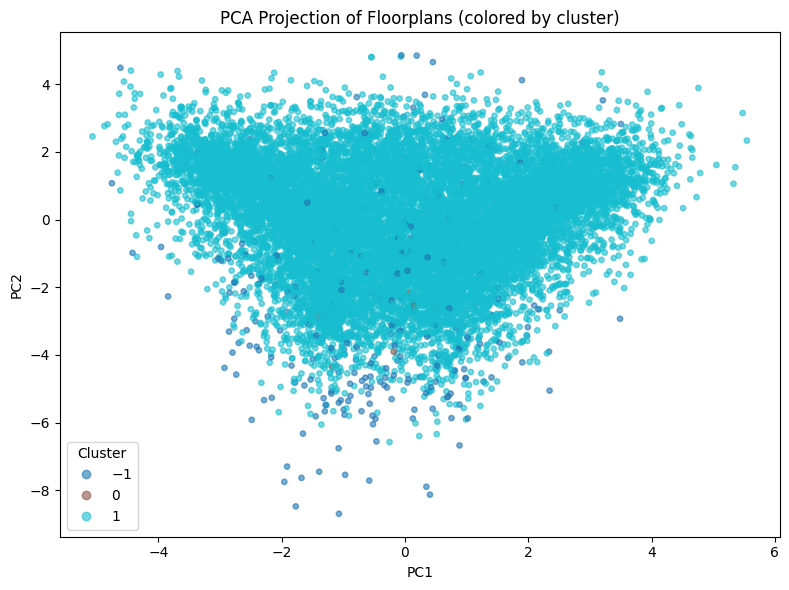

In [50]:
num_data = 15000
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca50[:num_data, 0],
    X_pca50[:num_data, 1],
    c=cluster_labels_hdb[:num_data],
    cmap="tab10",
    s=15,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Floorplans (colored by cluster)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

In [18]:
linkage_matrix = sch.linkage(X_pca50[:40000], method='ward')

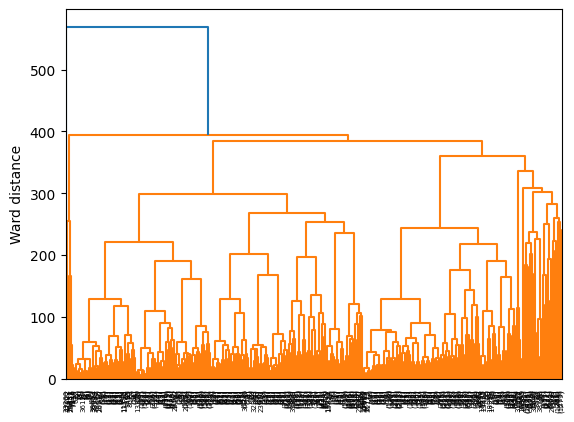

In [19]:
sch.dendrogram(linkage_matrix, truncate_mode='level', p=10)
plt.ylabel("Ward distance")
plt.show()

In [20]:
clusterer = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels = clusterer.fit_predict(X_pca50[:40000])

In [29]:
clusterer = AgglomerativeClustering(n_clusters=10, linkage='ward')
labels = clusterer.fit_predict(X_pca50[:40000])

In [30]:
cnt = Counter(labels)

for lbl, count in sorted(cnt.items()):
    if lbl == -1:
        print(f"  Noise points: {count}")
    else:
        print(f"  Cluster {lbl:>2}: {count} plans")

  Cluster  0: 11189 plans
  Cluster  1: 3076 plans
  Cluster  2: 6 plans
  Cluster  3: 6752 plans
  Cluster  4: 2641 plans
  Cluster  5: 5 plans
  Cluster  6: 1 plans
  Cluster  7: 1 plans
  Cluster  8: 5507 plans
  Cluster  9: 10822 plans


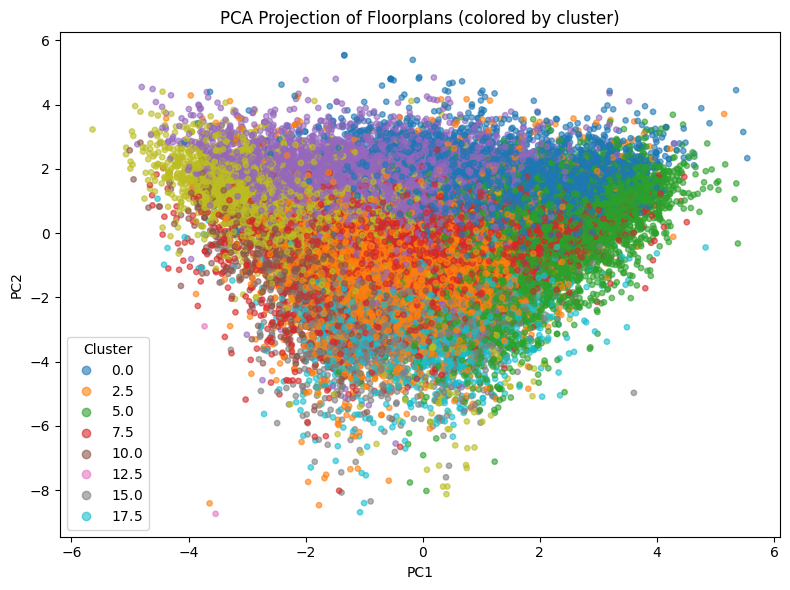

In [28]:
num_data = 40000
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca50[:num_data, 0],
    X_pca50[:num_data, 1],
    c=labels[:num_data],
    cmap="tab10",
    s=15,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Floorplans (colored by cluster)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()